<a href="https://colab.research.google.com/github/Ketan19-hue/KETAN_2026D0031101002/blob/main/hospitalreadmisson2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(2000, 12)
age                 0
heart_rate          0
bp                  0
glucose             0
prior_admissions    0
prior_er_visits     0
length_of_stay      0
diabetes            0
heart_failure       0
kidney_disease      0
copd                0
readmitted_30d      0
dtype: int64


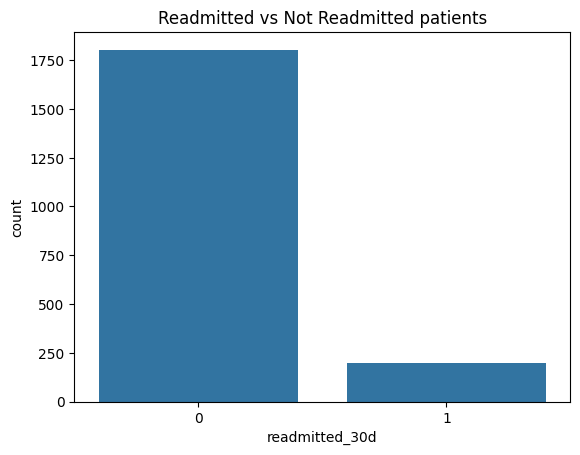

(2000, 11)
(2000,)
Train size: 1600
Test size: 400
Model trained
ROC-AUC Score: 0.741


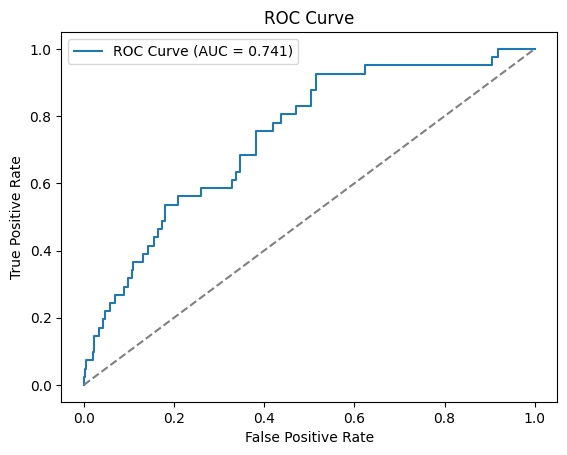

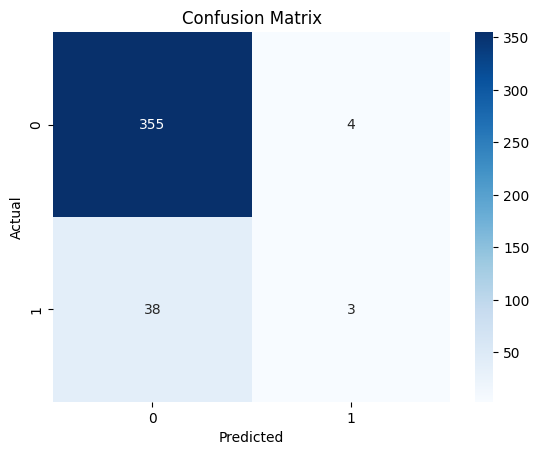

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       359
           1       0.43      0.07      0.12        41

    accuracy                           0.90       400
   macro avg       0.67      0.53      0.53       400
weighted avg       0.85      0.90      0.86       400

Confusion matrix at threshold 0.3:
[[342  17]
 [ 32   9]]

False Negatives at 0.5 threshold: 38
False Negatives at 0.3 threshold: 32

False Positives at 0.5 threshold: 4
False Positives at 0.3 threshold: 17


In [ ]:
# STEP-1 (IMPORTING LIBRARIES)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

#Step 2: Creating the patient data
# Since I don't have a real csv file, I am generating random patient data using numpy. I am keeping the number of patients as 2000

np.random.seed(42)
n = 2000

age = np.random.normal(60, 15, n).clip(18, 95)
heart_rate = np.random.normal(80, 12, n).clip(50, 140)
bp = np.random.normal(130, 20, n).clip(80, 200)
glucose = np.random.normal(110, 35, n).clip(60, 300)

prior_admissions = np.random.poisson(1.2, n)
prior_er_visits = np.random.poisson(0.8, n)
length_of_stay = np.random.poisson(4, n).clip(1, 30)

diabetes = np.random.binomial(1, 0.30, n)
heart_failure = np.random.binomial(1, 0.20, n)
kidney_disease = np.random.binomial(1, 0.15, n)
copd = np.random.binomial(1, 0.18, n)

# making a risk value so that readmission depends on these factors
# (this is just so the fake data makes some sense, not real medical formula)
risk = (0.03*(age-60) + 0.35*prior_admissions + 0.25*prior_er_visits + 0.10*length_of_stay
        + 0.8*diabetes + 1.1*heart_failure + 0.9*kidney_disease + 0.7*copd
        + 0.02*(glucose-110) - 4.5)

prob = 1 / (1 + np.exp(-risk))
readmitted = np.random.binomial(1, prob)

data = pd.DataFrame({
    'age': age.round(0),
    'heart_rate': heart_rate.round(0),
    'bp': bp.round(0),
    'glucose': glucose.round(0),
    'prior_admissions': prior_admissions,
    'prior_er_visits': prior_er_visits,
    'length_of_stay': length_of_stay,
    'diabetes': diabetes,
    'heart_failure': heart_failure,
    'kidney_disease': kidney_disease,
    'copd': copd,
    'readmitted_30d': readmitted
})

data.head()

# STEP -3 BASIC DATA CHECKING (EDA - EXPLORARTORY DATA ANALYSIS)

print(data.shape)
print(data.isnull().sum())
data.describe()

# checking how many patients got readmitted and how many did not
data['readmitted_30d'].value_counts()

sns.countplot(x='readmitted_30d', data=data)
plt.title('Readmitted vs Not Readmitted patients')
plt.show()

# STEP -4 SPLLTING DATA INTO X AND Y

X = data.drop('readmitted_30d', axis=1)
y = data['readmitted_30d']

print(X.shape)
print(y.shape)

# STEP - 5 TRAIN TEST SPLIT (80 -20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# STEP - 6 FEATURE SCALING

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# STEP - 7 TRAINING LOGISTIC REGRESSION MODEL WITH L2 REGULARIZATION

model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
model.fit(X_train_sc, y_train)

print("Model trained")

# STEP - 8 CHECKING MODEL COEFFICIENTS

coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef = coef.sort_values(by='Coefficient', ascending=False)
coef

# STEP - 9 PREDICTING ON TEST DATA

y_pred = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

result = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred, 'Probability': y_pred_prob.round(2)})
result.head(10)

# STEP - 10 MODEL EVAULATION USING ROC - AUC

auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", round(auc, 3))

fpr, tpr, thresh = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.3f)' % auc)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# STEP - 11 CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

# STEP - 12 TRYING A LOWER THRESHOLD TO REDUCE FALSE NEGATIVES

new_pred = (y_pred_prob >= 0.3).astype(int)

cm2 = confusion_matrix(y_test, new_pred)
print("Confusion matrix at threshold 0.3:")
print(cm2)

print("\nFalse Negatives at 0.5 threshold:", cm[1][0])
print("False Negatives at 0.3 threshold:", cm2[1][0])
print("\nFalse Positives at 0.5 threshold:", cm[0][1])
print("False Positives at 0.3 threshold:", cm2[0][1])

# CONCLUSION

